## Imports and setup

In [2]:
import os
import json
import sys
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import medmnist
from medmnist import INFO

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

try:
    NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # In Jupyter, __file__ usually doesn't exist
    NOTEBOOK_DIR = os.getcwd()

# If this notebook lives in "notebooks/", repo root is its parent
if os.path.basename(NOTEBOOK_DIR) == "notebooks":
    REPO_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
else:
    # Fall back to "one level up" behavior
    REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add repo root so `from src...` imports work
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

# Run-specific results directory
RESULTS_ROOT = os.path.join(REPO_ROOT, "results")
TRIAL_NUM = "04"
RUN_ID = f"Trial{TRIAL_NUM}_{datetime.now().strftime('%Y-%m-%d_%H.%M.%S')}"

RUN_DIR = os.path.join(RESULTS_ROOT, "runs", RUN_ID)
FIG_DIR = os.path.join(RUN_DIR, "figures")

os.makedirs(FIG_DIR, exist_ok=True)
print("Saving this run to:", RUN_DIR)

from src.model3d import Small3DCNN, Deep3DCNN

from skimage import measure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from src.train_utils import TrainConfig, set_seed, train_one_epoch, evaluate, evaluate_loss, save_json, save_checkpoint
from src.dataset_utils import IQOTHNCCDDataset, LungCancerDataset, LUNA16Dataset
from torch.utils.data import ConcatDataset

# ----------- Saving locations -----------

# Saving location for metrics 
metrics_path = os.path.join(RUN_DIR, "metrics.json")

# Saving location for plots 
train_loss_path = os.path.join(FIG_DIR, f"train_loss_{RUN_ID}.png")
confusion_matrix_path = os.path.join(FIG_DIR, f"confusion_matrix_{RUN_ID}.png")
table_path = os.path.join(FIG_DIR, f"results_table_{RUN_ID}.png")


Saving this run to: /Users/toriav/Desktop/Erem/CMPE 401/lung-nodule-3d/results/runs/Trial04_2026-04-11_21.40.31


## Config and device

In [3]:
cfg = TrainConfig(
    epochs=60,
    lr=3e-4,
    weight_decay=1e-4,
    batch_size=128,

    # In macOS notebooks, multiprocessing can break with custom collate_fn
    # Keeping num_workers=0 avoids worker spawn/pickling issues
    num_workers=0,

    # Seed is set for more repeatable runs
    seed=42,

    # Default decision threshold for converting probability -> class label
    threshold=0.5,

    # Scheduler patience kept from Trial 3; CosineAnnealingLR is used in Trial 4
    scheduler_patience=6
)

# Use GPU if available, otherwise CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Set random seeds across libraries to reduce run-to-run variation
set_seed(cfg.seed)

# Save plots and figures into this folder
os.makedirs("results/figures", exist_ok=True)

device: cpu


## Load NoduleMNIST3D

In [4]:
data_flag = "nodulemnist3d"
info = INFO[data_flag]

# Dataset class name is stored as a string in INFO; fetch the class object
DataClass = getattr(medmnist, info["python_class"])

print("Task:", info["task"])
print("Labels:", info["label"])
print("Channels:", info["n_channels"])

# Some MedMNIST versions omit n_classes; fallback to the number of labels
n_classes = info.get("n_classes", len(info["label"]))
print("Num classes:", n_classes)

Task: binary-class
Labels: {'0': 'benign', '1': 'malignant'}
Channels: 1
Num classes: 2


## Dataset Splitting

In [5]:
# MedMNIST downloads automatically to its cache location when download=True
train_ds = DataClass(split="train", download=True)
val_ds   = DataClass(split="val", download=True)
test_ds  = DataClass(split="test", download=True)

# Quick check - dataset sizes should match expected counts
print("sizes:", len(train_ds), len(val_ds), len(test_ds))

sizes: 1158 165 310


## External Datasets

Two additional datasets are loaded alongside NoduleMNIST3D to broaden
scanner and pathology diversity:

| Dataset | Format | Classes |
|---|---|---|
| **IQ-OTH:NCCD** | 2D JPG slices (stratified 80/10/10 split) | Benign · Malignant · Normal |
| **LungcancerDataSet** | 2D JPG/PNG slices (pre-split train/valid/test) | Benign · Malignant · Normal · 3 carcinoma sub-types |

Because the model expects 28×28×28 voxel volumes, each 2-D slice is
resized to 28×28 and **repeated 28 times along the depth axis** to form
a pseudo-3D volume.  Labels are collapsed to binary (0 = benign/normal,
1 = malignant).

In [6]:
# Paths to the two external datasets inside data/
IQOTH_ROOT      = os.path.join(REPO_ROOT, "data", "IQ-OTH:NCCD")
LUNGCANCER_ROOT = os.path.join(REPO_ROOT, "data", "LungcancerDataSet")

iqoth_train = IQOTHNCCDDataset(IQOTH_ROOT, split="train", seed=cfg.seed)
iqoth_val   = IQOTHNCCDDataset(IQOTH_ROOT, split="val",   seed=cfg.seed)
iqoth_test  = IQOTHNCCDDataset(IQOTH_ROOT, split="test",  seed=cfg.seed)

lcd_train = LungCancerDataset(LUNGCANCER_ROOT, split="train")
lcd_val   = LungCancerDataset(LUNGCANCER_ROOT, split="val")
lcd_test  = LungCancerDataset(LUNGCANCER_ROOT, split="test")

print("IQ-OTH:NCCD    train/val/test:", len(iqoth_train), len(iqoth_val), len(iqoth_test))
print("LungcancerDataSet train/val/test:", len(lcd_train), len(lcd_val), len(lcd_test))

IQ-OTH:NCCD    train/val/test: 877 110 110
LungcancerDataSet train/val/test: 1460 142 475


In [7]:
# LUNA16 — genuine 3D CT nodule patches
# Patches are extracted at construction time (loads each .mhd scan once).
# This takes ~2-3 minutes; subsequent epochs are fast since patches are in memory.
LUNA16_ROOT = os.path.join(REPO_ROOT, "data", "Luna16")

luna16_train = LUNA16Dataset(LUNA16_ROOT, split="train", neg_per_scan=3, seed=cfg.seed)
luna16_val   = LUNA16Dataset(LUNA16_ROOT, split="val",   neg_per_scan=3, seed=cfg.seed)
luna16_test  = LUNA16Dataset(LUNA16_ROOT, split="test",  neg_per_scan=3, seed=cfg.seed)

print("LUNA16 train/val/test:", len(luna16_train), len(luna16_val), len(luna16_test))


LUNA16 [train]: extracting 1560 patches from 442 scans …


  done — 1560 patches  (pos=492  neg=1068)
LUNA16 [val]: extracting 195 patches from 165 scans …


  done — 195 patches  (pos=62  neg=133)
LUNA16 [test]: extracting 195 patches from 155 scans …


  done — 195 patches  (pos=61  neg=134)
LUNA16 train/val/test: 1560 195 195


In [8]:
# Combined datasets: NoduleMNIST3D + IQ-OTH:NCCD + LungcancerDataSet + LUNA16
# The NoduleMNIST3D test set is kept separate so evaluation is
# apples-to-apples with previous trials.
combined_train_ds = ConcatDataset([train_ds, iqoth_train, lcd_train, luna16_train])
combined_val_ds   = ConcatDataset([val_ds,   iqoth_val,   lcd_val,   luna16_val])
combined_test_ds  = ConcatDataset([test_ds,  iqoth_test,  lcd_test,  luna16_test])

print("Combined train:", len(combined_train_ds))
print("Combined val  :", len(combined_val_ds))
print("Combined test :", len(combined_test_ds))
print("NoduleMNIST3D test (apples-to-apples):", len(test_ds))

Combined train: 5055
Combined val  : 612
Combined test : 1090
NoduleMNIST3D test (apples-to-apples): 310


Important note: MedMNIST labels are typically shaped (N, 1). We’ll flatten later.

## Handle class imbalance helper
### Using `pos_weight`

In [9]:
def get_label_array(ds):
    # Works with MedMNIST and Pseudo3DDataset: ds[i][1] is shape (1,)
    y = [int(np.array(ds[i][1]).reshape(-1)[0]) for i in range(len(ds))]
    return np.array(y, dtype=int)

# Use the combined training set for class-balance weighting
y_train = get_label_array(combined_train_ds)
n_pos = int((y_train == 1).sum())
n_neg = int((y_train == 0).sum())

print("combined train positives:", n_pos, "  negatives:", n_neg)

# pos_weight = neg/pos is the standard weighting for BCEWithLogitsLoss
pos_weight_value = (n_neg / max(n_pos, 1))
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=device)

print("pos_weight:", pos_weight_value)

combined train positives: 2161   negatives: 2894
pos_weight: 1.3391948172142527


## DataLoader

In [10]:
import torch.nn.functional as F

def collate_fn(batch, train=False):
    """Collate and normalize a batch; apply enhanced 3D augmentation during training."""
    xs, ys = zip(*batch)

    x = torch.tensor(np.stack(xs)).float()
    y = torch.tensor(np.stack(ys)).long()

    # Ensure x is (B, 1, D, H, W)
    if x.ndim == 4:
        x = x.unsqueeze(1)

    # ---- Per-volume standardization ----
    eps = 1e-6
    mean = x.mean(dim=(2, 3, 4), keepdim=True)
    std  = x.std(dim=(2, 3, 4), keepdim=True)
    x = (x - mean) / (std + eps)

    # ---- Enhanced 3D augmentation (train only) ----
    if train:
        # Random flips along each spatial axis
        for dim in [2, 3, 4]:
            if torch.rand(1).item() < 0.5:
                x = torch.flip(x, dims=[dim])

        # Random 90-degree rotation in the axial (H-W) plane
        if torch.rand(1).item() < 0.3:
            k = torch.randint(1, 4, (1,)).item()
            x = torch.rot90(x, k=k, dims=[3, 4])

        # Mild zoom/crop: upsample by 1.0–1.15×, then center-crop back
        if torch.rand(1).item() < 0.3:
            scale = 1.0 + 0.15 * torch.rand(1).item()
            D, H, W = x.shape[2], x.shape[3], x.shape[4]
            new_D = max(int(D * scale), D + 1)
            x_zoom = F.interpolate(
                x, size=(new_D, new_D, new_D),
                mode="trilinear", align_corners=False,
            )
            s = (new_D - D) // 2
            x = x_zoom[:, :, s:s+D, s:s+H, s:s+W]

        # Random intensity jitter (multiplicative scale)
        if torch.rand(1).item() < 0.3:
            scale = 0.9 + 0.2 * torch.rand(1).item()  # 0.9 – 1.1
            x = x * scale

        # Additive Gaussian noise
        if torch.rand(1).item() < 0.3:
            x = x + 0.05 * torch.randn_like(x)

    return x, y


train_loader = DataLoader(
    combined_train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=False,
    collate_fn=lambda b: collate_fn(b, train=True),
)

val_loader = DataLoader(
    combined_val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=False,
    collate_fn=lambda b: collate_fn(b, train=False),
)

# NoduleMNIST3D test only — keeps the apples-to-apples comparison with Trials 1 & 2
test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=False,
    collate_fn=lambda b: collate_fn(b, train=False),
)

# Full combined test loader (all three datasets) for holistic evaluation
combined_test_loader = DataLoader(
    combined_test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=False,
    collate_fn=lambda b: collate_fn(b, train=False),
)

# Per-dataset test loaders — for dataset-specific evaluation breakdown
iqoth_test_loader = DataLoader(
    ConcatDataset([iqoth_test]),
    batch_size=cfg.batch_size, shuffle=False,
    num_workers=cfg.num_workers, pin_memory=False,
    collate_fn=lambda b: collate_fn(b, train=False),
)

lcd_test_loader = DataLoader(
    ConcatDataset([lcd_test]),
    batch_size=cfg.batch_size, shuffle=False,
    num_workers=cfg.num_workers, pin_memory=False,
    collate_fn=lambda b: collate_fn(b, train=False),
)

luna16_test_loader = DataLoader(
    luna16_test,
    batch_size=cfg.batch_size, shuffle=False,
    num_workers=cfg.num_workers, pin_memory=False,
    collate_fn=lambda b: collate_fn(b, train=False),
)

print("nodule test batches:", len(test_loader),
      "  iqoth test batches:", len(iqoth_test_loader),
      "  lcd test batches:", len(lcd_test_loader),
      "  luna16 test batches:", len(luna16_test_loader),
      "  combined test batches:", len(combined_test_loader))

nodule test batches: 3   iqoth test batches: 1   lcd test batches: 4   luna16 test batches: 2   combined test batches: 9


## Data Visualization

x0 shape: (1, 28, 28, 28) y0: [0]


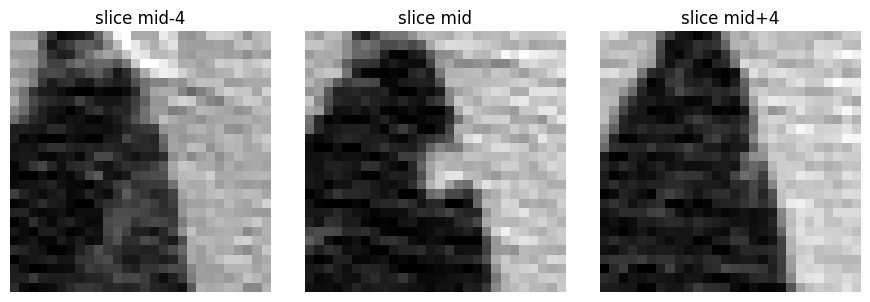

batch shapes: torch.Size([128, 1, 28, 28, 28]) torch.Size([128, 1])


In [11]:
# Inspect a single sample to confirm shapes and label format
x0, y0 = train_ds[0]
x0 = np.array(x0)
print("x0 shape:", x0.shape, "y0:", y0)

# For plotting, drop the channel dimension if present: (1, D, H, W) -> (D, H, W)
vol = x0[0] if x0.ndim == 4 else x0
mid = vol.shape[0] // 2

# Plot a few slices around the center depth
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(vol[mid-4], cmap="gray"); axes[0].set_title("slice mid-4"); axes[0].axis("off")
axes[1].imshow(vol[mid],   cmap="gray"); axes[1].set_title("slice mid");   axes[1].axis("off")
axes[2].imshow(vol[mid+4], cmap="gray"); axes[2].set_title("slice mid+4"); axes[2].axis("off")
plt.tight_layout()
plt.show()

# Confirm the DataLoader batch matches the 3D CNN expectation
xb, yb = next(iter(train_loader))
print("batch shapes:", xb.shape, yb.shape)

## Case Examples: Benign vs Malignant

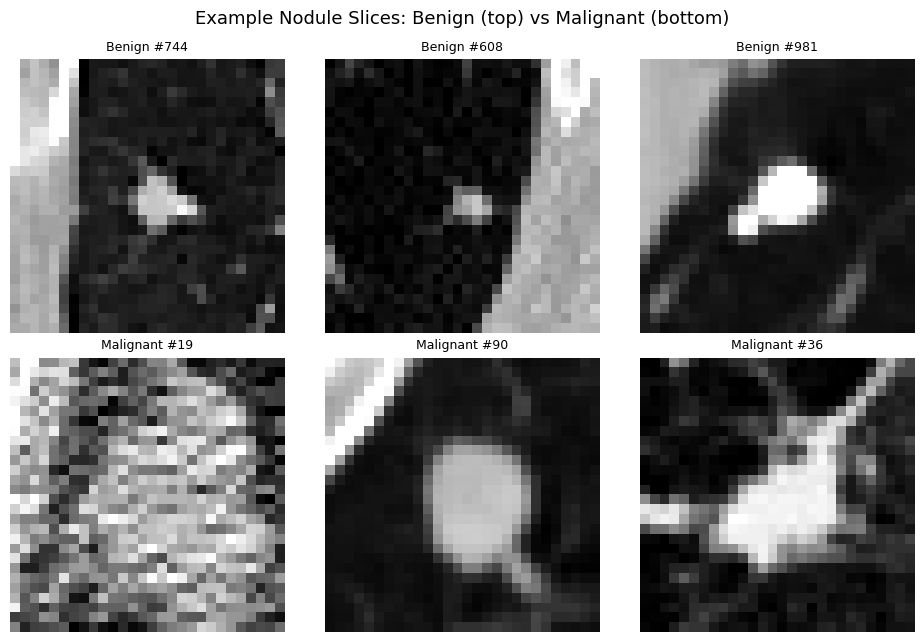

In [12]:
# Representative slices for each class

def show_class_examples(ds, n_per_class=3, seed=0):
    rng = np.random.default_rng(seed)
    y_all = get_label_array(ds)

    benign_idx    = np.where(y_all == 0)[0]
    malignant_idx = np.where(y_all == 1)[0]

    chosen_b = rng.choice(benign_idx,    size=n_per_class, replace=False)
    chosen_m = rng.choice(malignant_idx, size=n_per_class, replace=False)

    fig, axes = plt.subplots(
        2, n_per_class, figsize=(n_per_class * 3.2, 6.5)
    )
    fig.suptitle("Example Nodule Slices: Benign (top) vs Malignant (bottom)", fontsize=13)

    for col, idx in enumerate(chosen_b):
        vol = np.array(ds[idx][0])            # (1, 28, 28, 28) or (28,28,28)
        vol = vol[0] if vol.ndim == 4 else vol
        mid = vol.shape[0] // 2
        axes[0, col].imshow(vol[mid], cmap="gray")
        axes[0, col].set_title(f"Benign #{idx}", fontsize=9)
        axes[0, col].axis("off")

    for col, idx in enumerate(chosen_m):
        vol = np.array(ds[idx][0])
        vol = vol[0] if vol.ndim == 4 else vol
        mid = vol.shape[0] // 2
        axes[1, col].imshow(vol[mid], cmap="gray")
        axes[1, col].set_title(f"Malignant #{idx}", fontsize=9)
        axes[1, col].axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"case_examples_{RUN_ID}.png"), dpi=200)
    plt.show()

show_class_examples(train_ds, n_per_class=3)

## 3D Surface Visualization

Using marching cubes to render the nodule as a 3D mesh surface — adapted from Guido Zuidhof's DICOM preprocessing notebook. The threshold controls which voxel intensity is treated as the nodule boundary.

No surface found at threshold=80 for "Benign nodule (3D surface)"
No surface found at threshold=80 for "Malignant nodule (3D surface)"


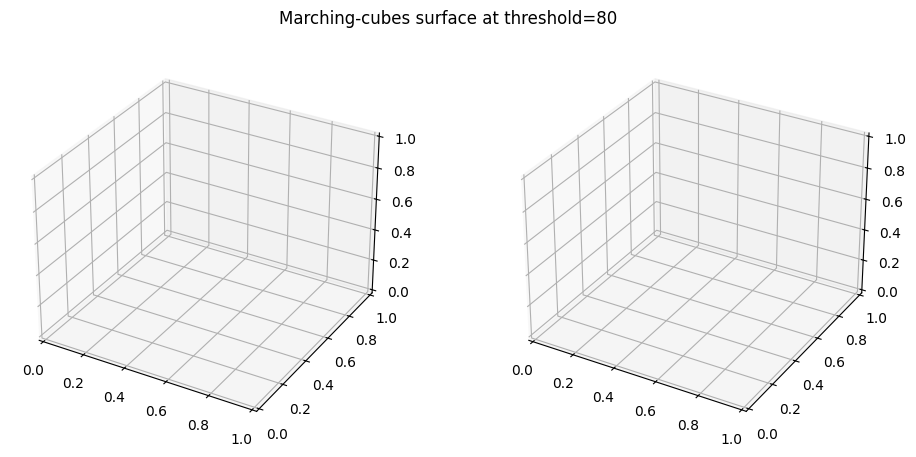

In [13]:
# 3D surface visualization using marching cubes
# Adapted from pulmonary DICOM preprocessing (Kaggle) for 28×28×28 uint8 volumes

def plot_3d_nodule(vol, threshold=80, color="steelblue", title="", ax=None):
    """
    Render a 28×28×28 nodule volume as a 3D mesh surface using marching cubes.

    vol       : (1, D, H, W) or (D, H, W) uint8 numpy array
    threshold : voxel intensity cutoff for the isosurface (0-255 scale)
    """
    if vol.ndim == 4:
        vol = vol[0]

    try:
        verts, faces, _, _ = measure.marching_cubes(vol, level=threshold)
    except (ValueError, RuntimeError):
        print(f"No surface found at threshold={threshold} for \"{title}\"")
        return

    standalone = ax is None
    if standalone:
        fig = plt.figure(figsize=(4.5, 4.5))
        ax = fig.add_subplot(111, projection='3d')

    mesh = Poly3DCollection(verts[faces], alpha=0.35)
    mesh.set_facecolor(color)
    mesh.set_edgecolor("none")
    ax.add_collection3d(mesh)
    ax.set_xlim(0, vol.shape[0])
    ax.set_ylim(0, vol.shape[1])
    ax.set_zlim(0, vol.shape[2])
    ax.set_title(title or f"3D surface (thr={threshold})", fontsize=10)
    ax.set_xlabel("D"); ax.set_ylabel("H"); ax.set_zlabel("W")

    if standalone:
        plt.tight_layout()
        plt.show()


def show_3d_class_examples(ds, threshold=80, seed=0):
    """Side-by-side 3D surface renders for one benign and one malignant nodule."""
    rng = np.random.default_rng(seed)
    y_all = get_label_array(ds)

    idx_b = int(rng.choice(np.where(y_all == 0)[0]))
    idx_m = int(rng.choice(np.where(y_all == 1)[0]))

    fig = plt.figure(figsize=(10, 4.5))
    for col, (label_name, idx, color) in enumerate(
        [("Benign", idx_b, "steelblue"), ("Malignant", idx_m, "tomato")]
    ):
        ax = fig.add_subplot(1, 2, col + 1, projection='3d')
        vol = np.array(ds[idx][0])
        plot_3d_nodule(vol, threshold=threshold, color=color,
                       title=f"{label_name} nodule (3D surface)", ax=ax)

    plt.suptitle(f"Marching-cubes surface at threshold={threshold}", fontsize=12)
    plt.tight_layout()
    plt.show()


show_3d_class_examples(train_ds, threshold=80)


## Multi-View Slice Comparison (Axial / Sagittal / Coronal)

Displays the three orthogonal mid-plane cuts — the same views radiologists use when reading a CT scan.

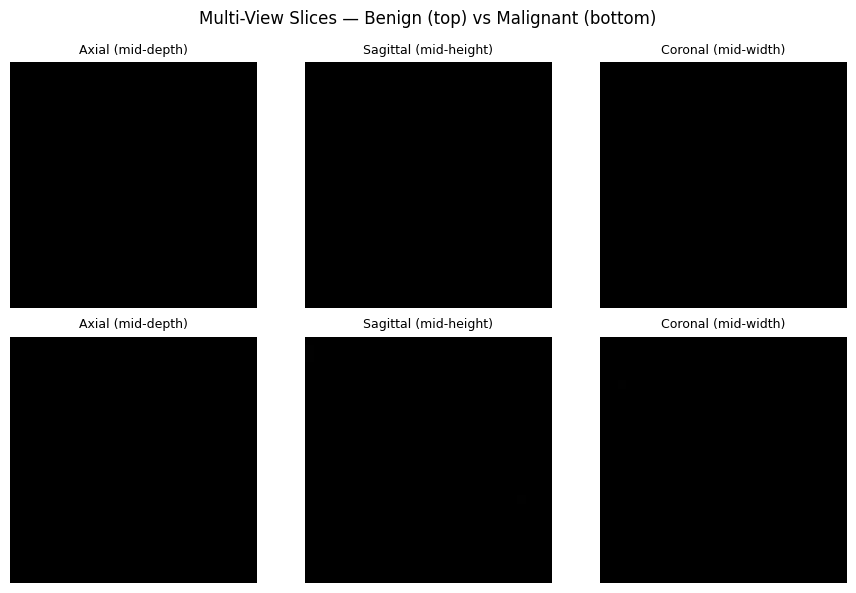

In [14]:
# Multi-view visualization: axial, sagittal, and coronal mid-plane slices
# Mirrors standard radiological CT viewing protocol

def show_multiview(vol, title="", cmap="gray", ax_row=None):
    """
    Display axial (D), sagittal (H), and coronal (W) mid-plane slices.
    vol: (1, D, H, W) or (D, H, W) uint8 array.
    """
    if vol.ndim == 4:
        vol = vol[0]
    d, h, w = vol.shape

    if ax_row is None:
        fig, axes = plt.subplots(1, 3, figsize=(9, 3))
        standalone = True
    else:
        axes = ax_row
        standalone = False

    axes[0].imshow(vol[d // 2, :, :], cmap=cmap, vmin=0, vmax=255)
    axes[0].set_title("Axial (mid-depth)", fontsize=9)
    axes[1].imshow(vol[:, h // 2, :], cmap=cmap, vmin=0, vmax=255)
    axes[1].set_title("Sagittal (mid-height)", fontsize=9)
    axes[2].imshow(vol[:, :, w // 2], cmap=cmap, vmin=0, vmax=255)
    axes[2].set_title("Coronal (mid-width)", fontsize=9)

    for ax in axes:
        ax.axis("off")

    if standalone:
        fig.suptitle(title, fontsize=11)
        plt.tight_layout()
        plt.show()


def show_multiview_class_comparison(ds, seed=0):
    """Show axial/sagittal/coronal views for one benign and one malignant sample."""
    rng = np.random.default_rng(seed)
    y_all = get_label_array(ds)

    idx_b = int(rng.choice(np.where(y_all == 0)[0]))
    idx_m = int(rng.choice(np.where(y_all == 1)[0]))

    fig, axes = plt.subplots(2, 3, figsize=(9, 6))
    fig.suptitle("Multi-View Slices — Benign (top) vs Malignant (bottom)", fontsize=12)

    show_multiview(np.array(ds[idx_b][0]), ax_row=axes[0])
    show_multiview(np.array(ds[idx_m][0]), ax_row=axes[1])

    axes[0][0].set_ylabel("Benign", fontsize=10, labelpad=8)
    axes[1][0].set_ylabel("Malignant", fontsize=10, labelpad=8)
    plt.tight_layout()
    plt.show()


show_multiview_class_comparison(train_ds)


## Model, Loss, and Optimizer

In [15]:
# Trial 4: Deep3DCNN — wider channels and an extra MaxPool stage
# ~3.53 M params vs ~884 K for Small3DCNN (4× larger)
model = Deep3DCNN(dropout_p=0.4).to(device)

# BCEWithLogitsLoss expects raw logits
# Accounting for class imbalance to improve recall score
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# AdamW optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

# Trial 4: CosineAnnealingLR — smooth LR decay over all epochs
# Avoids the plateau-sensitive step behaviour of ReduceLROnPlateau
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=cfg.epochs,
    eta_min=1e-6
)

print("num params:", sum(p.numel() for p in model.parameters()))

num params: 3530529


## Training loop

In [16]:
# Trial 4: training on combined NoduleMNIST3D + IQ-OTH:NCCD + LungcancerDataSet
# Store training loss and validation metrics per epoch
history = {"train_loss": [], "val_loss": [], "val": []}
best_score = -1.0
best_epoch = -1

for epoch in range(1, cfg.epochs + 1):
    # One full pass over the training set
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)

    # Evaluate for validation loss (real BCE loss)
    val_loss = evaluate_loss(model, val_loader, criterion, device)

    # Evaluate on validation set at the current threshold
    # cfg.threshold (0.5) is only used here for epoch-level monitoring during training.
    # Final test evaluation always uses the threshold tuned on the validation set.
    val_metrics = evaluate(model, val_loader, device, threshold=cfg.threshold, criterion=criterion)
    val_metrics["val_loss"] = val_loss

    # Trial 4: CosineAnnealingLR steps every epoch (no metric needed)
    scheduler.step()

    print("lr:", optimizer.param_groups[0]["lr"])

    # Log metrics
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val"].append(val_metrics)

    print(
        f"epoch {epoch:02d} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | "
        f"val auroc {val_metrics['auroc']} | val f1 {val_metrics['f1']:.4f}"
    )

    # Saving location for results 
    best_ckpt_path = os.path.join(RUN_DIR, "best.pt")
    # prefer AUROC when available; fallback to F1
    score = val_metrics["auroc"] if val_metrics["auroc"] is not None else val_metrics["f1"]
    if score > best_score:
        best_score = score
        best_epoch = epoch
        save_checkpoint(
            best_ckpt_path,
            model,
            optimizer,
            epoch,
            {"val_metrics": val_metrics, "config": cfg.__dict__},
        )

# Save training history and the best epoch so results are reproducible
save_json(metrics_path, {"history": history, "best_epoch": best_epoch})
print("best_epoch:", best_epoch, "best_score:", best_score)

lr: 0.00029979511544580873
epoch 01 | train_loss 0.6749 | val_loss 0.6455 | val auroc 0.7856966845878136 | val f1 0.5623


lr: 0.0002991810233575568
epoch 02 | train_loss 0.5795 | val_loss 0.5932 | val auroc 0.8146505376344086 | val f1 0.7007


lr: 0.00029815940691897306
epoch 03 | train_loss 0.5330 | val_loss 0.8064 | val auroc 0.7457437275985663 | val f1 0.4290


lr: 0.0002967330663097039
epoch 04 | train_loss 0.4812 | val_loss 0.6708 | val auroc 0.8195564516129032 | val f1 0.6933


lr: 0.00029490591103021566
epoch 05 | train_loss 0.4556 | val_loss 0.6354 | val auroc 0.8571572580645161 | val f1 0.7376


...

lr: 4.266933690296051e-06
epoch 56 | train_loss 0.0992 | val_loss 0.3180 | val auroc 0.9669466845878136 | val f1 0.8667


lr: 2.840593081026921e-06
epoch 57 | train_loss 0.0925 | val_loss 0.3222 | val auroc 0.966621863799283 | val f1 0.8611


lr: 1.818976642443127e-06
epoch 58 | train_loss 0.0920 | val_loss 0.3102 | val auroc 0.9679995519713261 | val f1 0.8577


lr: 1.204884554191212e-06
epoch 59 | train_loss 0.0958 | val_loss 0.3274 | val auroc 0.967103494623656 | val f1 0.8627


lr: 1e-06
epoch 60 | train_loss 0.0845 | val_loss 0.3417 | val auroc 0.9655241935483871 | val f1 0.8566
best_epoch: 47 best_score: 0.9694220430107526


## Intermediate Feature Map Visualization

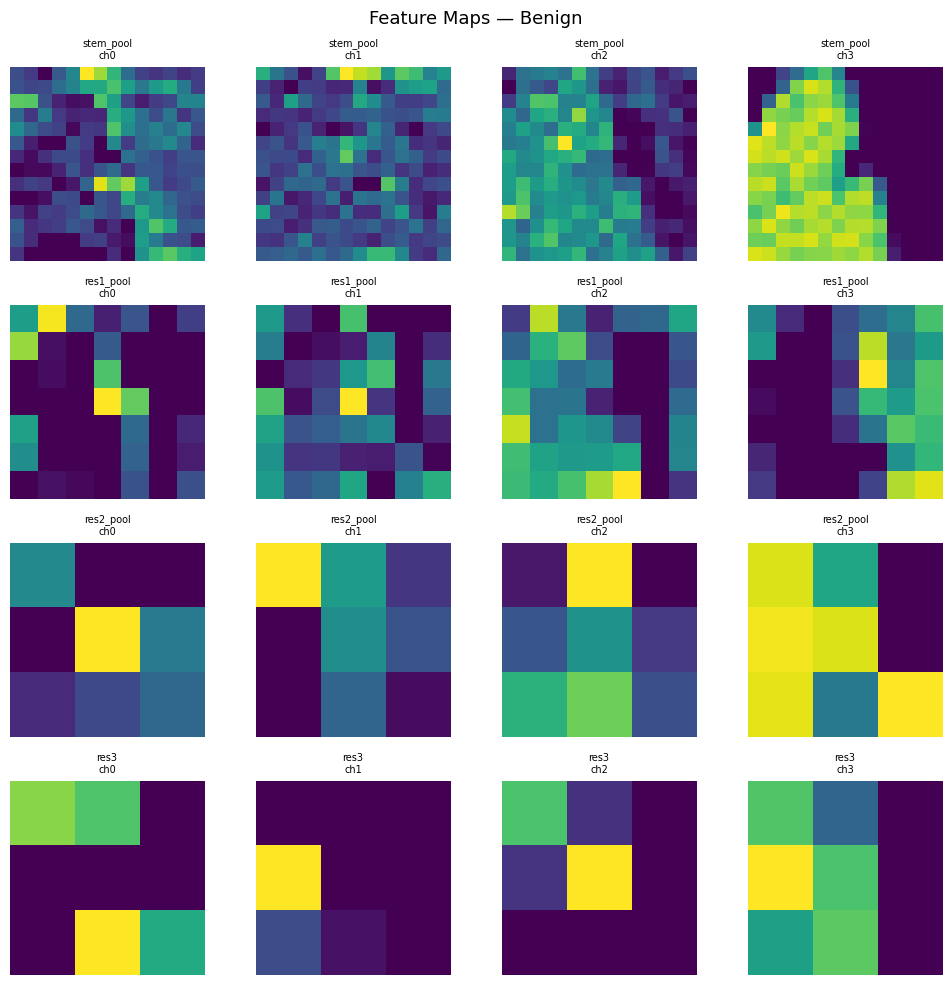

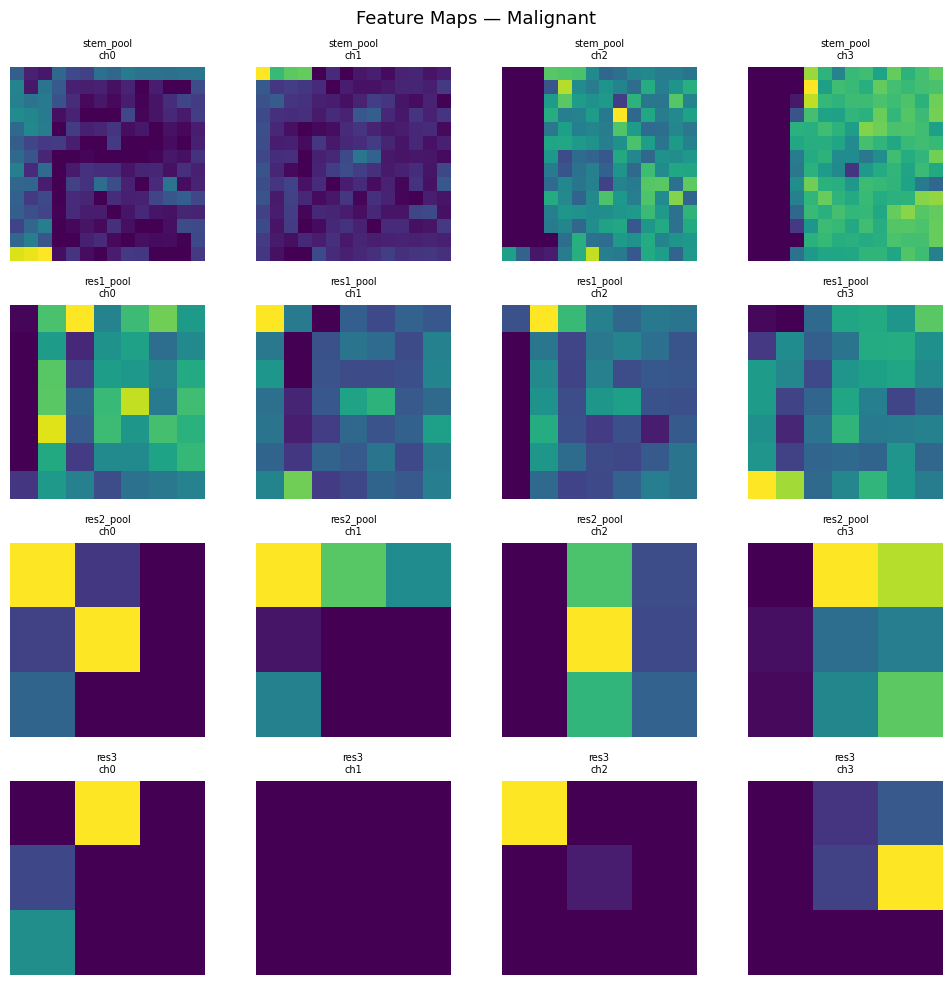

In [17]:
# Pick one benign and one malignant sample, run a forward pass,
# and display the first few channels of each residual stage.

def visualize_feature_maps(model, ds, device, n_channels=4):
    model.eval()
    y_all = get_label_array(ds)

    # pick first benign and first malignant
    idx_b = int(np.where(y_all == 0)[0][0])
    idx_m = int(np.where(y_all == 1)[0][0])

    for label_name, idx in [("Benign", idx_b), ("Malignant", idx_m)]:
        x_raw = np.array(ds[idx][0]).astype(np.float32)
        x_t   = torch.tensor(x_raw).unsqueeze(0)         # (1, 1, 28, 28, 28)
        if x_t.ndim == 4:
            x_t = x_t.unsqueeze(0)

        # Normalise the same way as collate_fn
        eps = 1e-6
        x_t = (x_t - x_t.mean()) / (x_t.std() + eps)
        x_t = x_t.to(device)

        with torch.no_grad():
            maps = model.get_feature_maps(x_t)

        stage_names = list(maps.keys())
        fig, axes = plt.subplots(
            len(stage_names), n_channels,
            figsize=(n_channels * 2.5, len(stage_names) * 2.5)
        )
        fig.suptitle(f"Feature Maps — {label_name}", fontsize=13)

        for row, sname in enumerate(stage_names):
            fmap = maps[sname][0]        # (C, D, H, W) – drop batch dim
            mid_d = fmap.shape[1] // 2  # middle depth slice
            for col in range(n_channels):
                ax = axes[row, col] if len(stage_names) > 1 else axes[col]
                ch_map = fmap[col, mid_d].numpy()
                ax.imshow(ch_map, cmap="viridis")
                ax.set_title(f"{sname}\nch{col}", fontsize=7)
                ax.axis("off")

        plt.tight_layout()
        plt.savefig(
            os.path.join(FIG_DIR, f"feature_maps_{label_name.lower()}_{RUN_ID}.png"),
            dpi=200
        )
        plt.show()

visualize_feature_maps(model, train_ds, device, n_channels=4)

## Threshold Tuning with Combined Validation Set

Sweep decision thresholds on the combined validation set and pick the one
that maximises F1. This tuned threshold is used for **all** final test evaluations.

In [18]:
@torch.no_grad()
def get_logits_and_labels(model, loader, device):
    model.eval()
    all_logits, all_y = [], []
    for x, y in loader:
        x = x.to(device)
        all_logits.append(model(x).cpu().numpy())
        all_y.append(y.numpy().reshape(-1))
    return np.concatenate(all_y).astype(int), np.concatenate(all_logits)

y_val, logits_val = get_logits_and_labels(model, val_loader, device)

from src.metrics import compute_binary_metrics

thresholds = np.linspace(0.05, 0.95, 19)
best = None
sweep_rows = []

for t in thresholds:
    met = compute_binary_metrics(y_val, logits_val, threshold=float(t))
    row = {"threshold": float(t), **{k: met[k] for k in
           ["f1","recall","precision","specificity","accuracy","auroc"]}}
    sweep_rows.append(row)
    if best is None or row["f1"] > best["f1"]:
        best = row

best_threshold = best["threshold"]
print(f"Best threshold by F1: {best_threshold:.2f}  "
      f"(F1={best['f1']:.3f}, Recall={best['recall']:.3f}, "
      f"Precision={best['precision']:.3f})")

Best threshold by F1: 0.85  (F1=0.886, Recall=0.871, Precision=0.901)


## Training Curves

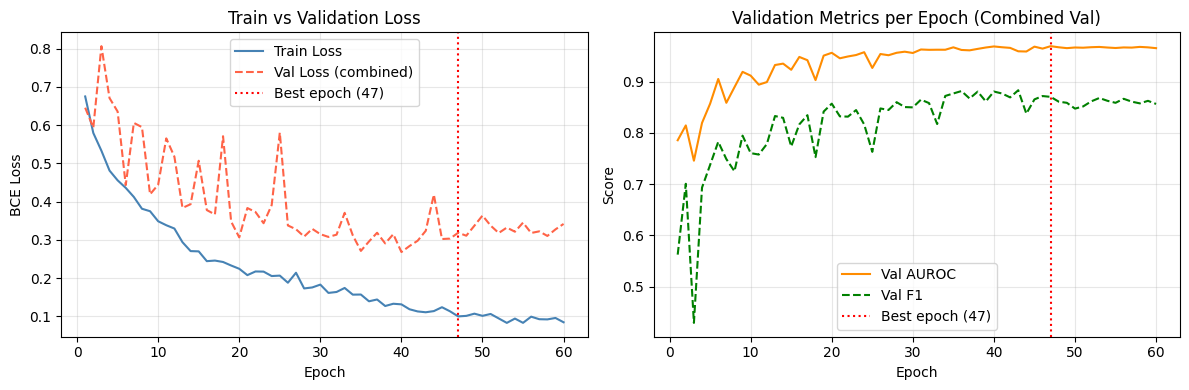

In [19]:
train_losses = history["train_loss"]
val_losses   = history["val_loss"]
val_aurocs   = [v["auroc"] for v in history["val"]]
val_f1s      = [v["f1"]    for v in history["val"]]

epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, train_losses, label="Train Loss", color="steelblue")
axes[0].plot(epochs_range, val_losses,   label="Val Loss (combined)", color="tomato", linestyle="--")
axes[0].axvline(best_epoch, color="red", linestyle=":", label=f"Best epoch ({best_epoch})")
axes[0].set_title("Train vs Validation Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, val_aurocs, label="Val AUROC", color="darkorange")
axes[1].plot(epochs_range, val_f1s,   label="Val F1",    color="green", linestyle="--")
axes[1].axvline(best_epoch, color="red", linestyle=":", label=f"Best epoch ({best_epoch})")
axes[1].set_title("Validation Metrics per Epoch (Combined Val)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"train_val_curves_{RUN_ID}.png"), dpi=200)
plt.show()

## Test Evaluation

Each dataset is evaluated with the threshold tuned on the combined validation set.
NoduleMNIST3D is kept as the primary apples-to-apples benchmark across trials.

In [20]:
nodule_test_tuned   = evaluate(model, test_loader,          device, threshold=best_threshold)
iqoth_test_tuned    = evaluate(model, iqoth_test_loader,     device, threshold=best_threshold)
lcd_test_tuned      = evaluate(model, lcd_test_loader,       device, threshold=best_threshold)
luna16_test_tuned   = evaluate(model, luna16_test_loader,     device, threshold=best_threshold)
combined_test_tuned = evaluate(model, combined_test_loader,  device, threshold=best_threshold)

print(f"Tuned threshold = {best_threshold:.2f}\n")
for name, m in [
    ("NoduleMNIST3D",     nodule_test_tuned),
    ("IQ-OTH:NCCD",       iqoth_test_tuned),
    ("LungcancerDataSet", lcd_test_tuned),
    ("LUNA16",            luna16_test_tuned),
    ("Combined",          combined_test_tuned),
]:
    print(f"{name:20s}  AUROC={m['auroc']:.3f}  F1={m['f1']:.3f}  "
          f"Recall={m['recall']:.3f}  Precision={m['precision']:.3f}  "
          f"Spec={m['specificity']:.3f}")

# Persist
with open(metrics_path, "r") as f:
    m_all = json.load(f)
m_all["best_threshold_val_f1"]         = best
m_all["test_nodule_threshold"]         = nodule_test_tuned
m_all["test_iqoth_threshold"]         = iqoth_test_tuned
m_all["test_lcd_threshold"]           = lcd_test_tuned
m_all["test_luna16_threshold"]        = luna16_test_tuned
m_all["test_combined_threshold"]      = combined_test_tuned
with open(metrics_path, "w") as f:
    json.dump(m_all, f, indent=2)
# Alias so the results table below can reference it
test_metrics_tuned = nodule_test_tuned

Tuned threshold = 0.85

NoduleMNIST3D         AUROC=0.830  F1=0.584  Recall=0.625  Precision=0.548  Spec=0.866
IQ-OTH:NCCD           AUROC=1.000  F1=1.000  Recall=1.000  Precision=1.000  Spec=1.000
LungcancerDataSet     AUROC=0.997  F1=0.964  Recall=0.933  Precision=0.997  Spec=0.993
LUNA16                AUROC=0.957  F1=0.870  Recall=0.770  Precision=1.000  Spec=1.000
Combined              AUROC=0.970  F1=0.907  Recall=0.883  Precision=0.931  Spec=0.940


## Confusion Matrices

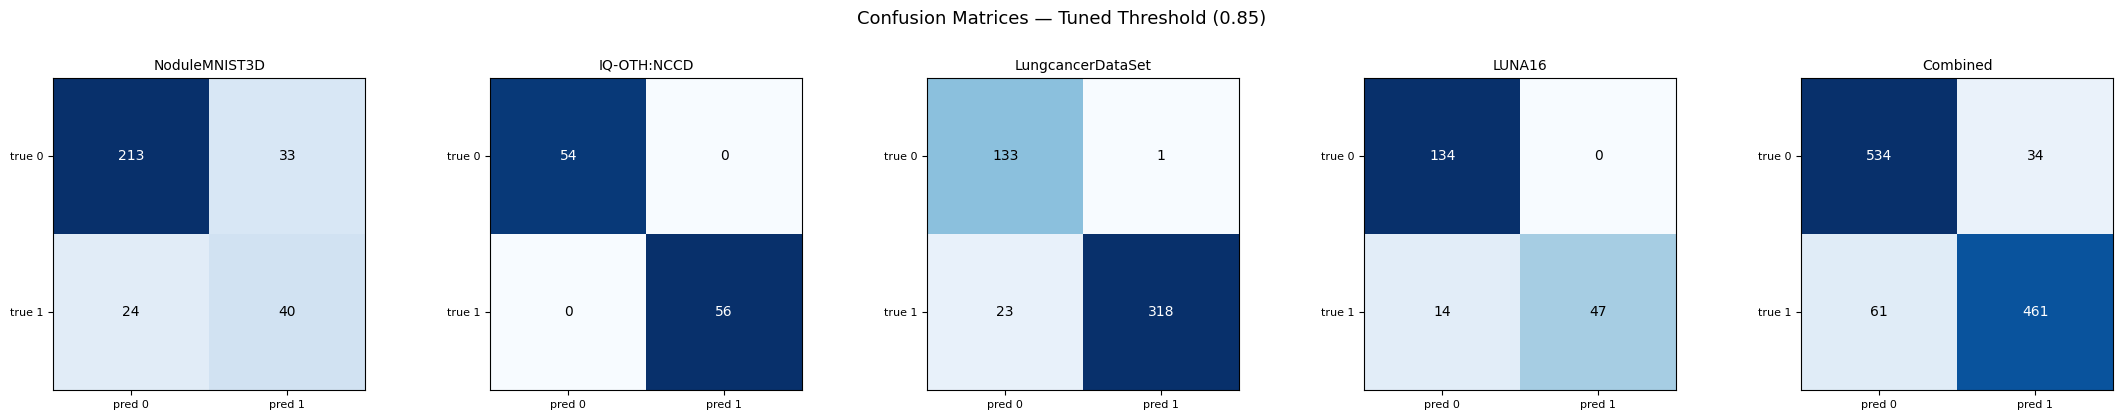

In [21]:
dataset_results_tuned = [
    ("NoduleMNIST3D",     nodule_test_tuned),
    ("IQ-OTH:NCCD",       iqoth_test_tuned),
    ("LungcancerDataSet", lcd_test_tuned),
    ("LUNA16",            luna16_test_tuned),
    ("Combined",          combined_test_tuned),
]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle(f"Confusion Matrices — Tuned Threshold ({best_threshold:.2f})", fontsize=13, y=1.02)

for ax, (name, met) in zip(axes, dataset_results_tuned):
    cm = np.array(met["confusion_matrix"])
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
    ax.set_title(name, fontsize=10)
    ax.set_xticks([0,1]); ax.set_xticklabels(["pred 0","pred 1"], fontsize=8)
    ax.set_yticks([0,1]); ax.set_yticklabels(["true 0","true 1"], fontsize=8)
    thresh_cm = cm.max() * 0.6
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha="center", va="center",
                    color="white" if cm[i,j] > thresh_cm else "black", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"confusion_matrices_tuned_{RUN_ID}.png"), dpi=200)
plt.show()

## Logistic Regression Baseline
### Flattened voxels, NoduleMNIST3D only

In [22]:
def flatten_dataset(ds):
    X, y = [], []
    for i in range(len(ds)):
        x_i, y_i = ds[i]
        X.append(np.array(x_i).astype(np.float32).reshape(-1))
        y.append(int(np.array(y_i).reshape(-1)[0]))
    return np.stack(X), np.array(y)

X_train_lr, y_train_lr = flatten_dataset(train_ds)
X_val_lr,   y_val_lr   = flatten_dataset(val_ds)
X_test_lr,  y_test_lr  = flatten_dataset(test_ds)

clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, class_weight="balanced")
)
clf.fit(X_train_lr, y_train_lr)

lr_metrics = compute_binary_metrics(
    y_test_lr, clf.decision_function(X_test_lr), threshold=0.5
)
print(lr_metrics)

with open(metrics_path, "r") as f:
    m_all = json.load(f)
m_all["logreg_baseline_test"] = lr_metrics
with open(metrics_path, "w") as f:
    json.dump(m_all, f, indent=2)

{'auroc': 0.8226626016260162, 'f1': 0.5384615384615384, 'accuracy': 0.8064516129032258, 'precision': 0.5303030303030303, 'recall': 0.546875, 'specificity': 0.8739837398373984, 'confusion_matrix': [[215, 31], [29, 35]]}


## Results Summary Table

3D CNN evaluated at the tuned threshold across all datasets, compared against
the NoduleMNIST3D logistic regression baseline.

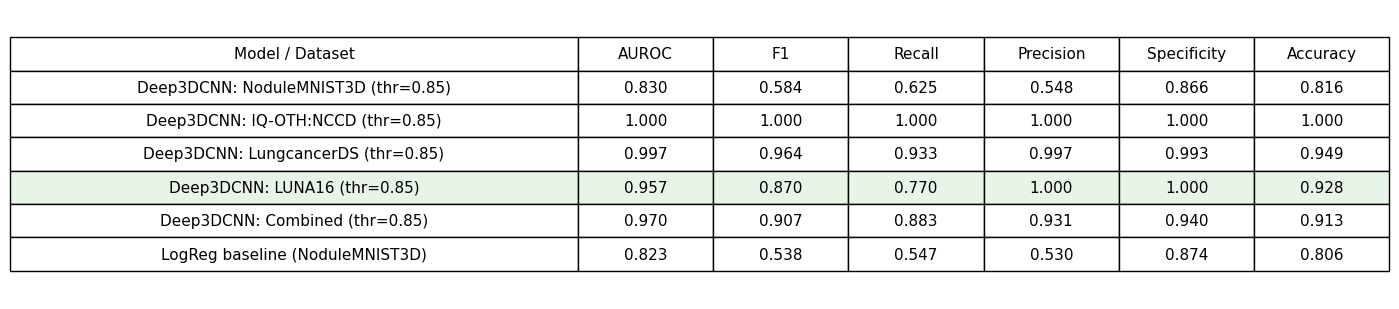

In [23]:
def fmt(v):
    return "N/A" if v is None else f"{v:.3f}"

def row_from_metrics(name, met):
    return [name,
            fmt(met.get("auroc")),
            fmt(met.get("f1")),
            fmt(met.get("recall")),
            fmt(met.get("precision")),
            fmt(met.get("specificity")),
            fmt(met.get("accuracy"))]

thr_label = f"thr={best_threshold:.2f}"
rows_table = [
    row_from_metrics(f"Deep3DCNN: NoduleMNIST3D ({thr_label})",   nodule_test_tuned),
    row_from_metrics(f"Deep3DCNN: IQ-OTH:NCCD ({thr_label})",     iqoth_test_tuned),
    row_from_metrics(f"Deep3DCNN: LungcancerDS ({thr_label})",     lcd_test_tuned),
    row_from_metrics(f"Deep3DCNN: LUNA16 ({thr_label})",           luna16_test_tuned),
    row_from_metrics(f"Deep3DCNN: Combined ({thr_label})",         combined_test_tuned),
    row_from_metrics("LogReg baseline (NoduleMNIST3D)",          lr_metrics),
]

col_labels = ["Model / Dataset", "AUROC", "F1", "Recall", "Precision", "Specificity", "Accuracy"]

fig, ax = plt.subplots(figsize=(14, 3.2))
ax.axis("off")
table = ax.table(
    cellText=rows_table,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
    colWidths=[0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.7)
for (r, c), cell in table.get_celld().items():
    if c == 0:
        cell.set_width(cell.get_width() * 2.1)
    # highlight the combined row
    if r == 4:
        cell.set_facecolor("#e8f4e8")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"results_table_{RUN_ID}.png"), dpi=300)
plt.show()